In [ ]:
# Importing libraries and dependencies
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [ ]:
# Load csv dataset into SQLite3
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
connection = sqlite3.connect("demo.db")
df.to_sql("stroke_data", connection, if_exists="replace")

In [ ]:
# Show a sample of the dataset after loading in SQLite
query = "SELECT * FROM stroke_data LIMIT 5"
df_sample = pd.read_sql(query, connection)
print(df_sample)

In [ ]:
# Show the number of records and columns of the dataset before synthesizing
df.shape

(5110, 12)

**Data Synthesizing**


In [18]:
# Detect metadata from the original dataset
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# Initialize the SDV synthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the original data
synthesizer.fit(df)

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sdv\single_table\base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sdv\single_table\base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [19]:
# Generate synthetic data (same number of rows as original data)
synthetic_data = synthesizer.sample(num_rows=len(df))

print("\nSynthetic Data:")
print(synthetic_data.head())


Synthetic Data:
         id  gender    age  hypertension  heart_disease ever_married  \
0   3525996  Female  70.97             0              0          Yes   
1   4651427    Male   5.06             0              0           No   
2  13030739    Male  21.51             0              0           No   
3   9215219    Male  30.99             0              0          Yes   
4  10439349    Male  14.91             0              0          Yes   

  work_type Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0   Private          Rural             130.61  30.6  formerly smoked       0  
1  Govt_job          Rural              88.98  18.3          Unknown       0  
2  children          Rural              74.25  21.7          Unknown       0  
3   Private          Rural             189.72  34.8     never smoked       1  
4   Private          Rural             123.59  30.3           smokes       0  


In [20]:
# Concatenate original and synthetic data
total_data = pd.concat([df, synthetic_data], ignore_index=True)

print("\ntotal Data:")
print(total_data.head())


total Data:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [21]:
# Connect to SQLite
connection = sqlite3.connect("demo.db")
# Save combined data to a new table
total_data.to_sql("total_table", connection, if_exists="replace", index=False)

# Close connection
connection.close()

print("Combined data saved to SQLite database successfully.")

Combined data saved to SQLite database successfully.


In [22]:
total_data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,1.022000e+04,10220.000000,10220.000000,10220.000000,10220.000000,9803.000000,10220.000000
mean,4.250227e+06,43.281111,0.097945,0.054305,113.704445,28.931929,0.049413
std,5.431846e+06,23.150373,0.297255,0.226630,53.127824,7.843879,0.216739
min,6.700000e+01,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,3.681325e+04,24.170000,0.000000,0.000000,74.107500,23.400000,0.000000
50%,7.255450e+04,44.335000,0.000000,0.000000,95.370000,28.000000,0.000000
75%,8.471824e+06,62.372500,0.000000,0.000000,139.682500,33.300000,0.000000
max,1.677449e+07,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [14]:
print(total_data.tail())

             id  gender    age  hypertension  heart_disease ever_married  \
10215  11702222  Female  77.36             0              0          Yes   
10216   3020045    Male  35.04             0              0          Yes   
10217  10060244  Female   4.52             0              0           No   
10218  13904875    Male  72.29             0              0          Yes   
10219  11110461    Male  74.17             0              0          Yes   

      work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
10215   Private          Urban              70.01  34.3     never smoked   
10216   Private          Rural              56.62  27.7  formerly smoked   
10217  children          Rural              55.86  18.1          Unknown   
10218   Private          Urban              56.02  36.6          Unknown   
10219   Private          Rural              71.36  24.9     never smoked   

       stroke  
10215       1  
10216       0  
10217       0  
10218       0  
10219 

In [23]:
# To ensure the synthetic data is add to the original data
total_data.shape

(10220, 12)

In [ ]:
total_data.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

**📌Key Measures of Tendencies:**


In [ ]:
# Calculating the mean of each numerical column
print("Mean ID:", total_data["id"].mean())
print("Mean Age:", total_data["age"].mean())
print("Mean Hypertension:", total_data["hypertension"].mean())
print("Mean Heart Disease:", total_data["heart_disease"].mean())
print("Mean Avg Glucose Level:", total_data["avg_glucose_level"].mean())
print("Mean BMI:", total_data["bmi"].mean())
print("Mean Stroke:", total_data["stroke"].mean())

Mean ID: 4250227.112915851
Mean Age: 43.28111056751468
Mean Hypertension: 0.09794520547945205
Mean Heart Disease: 0.05430528375733855
Mean Avg Glucose Level: 113.70444520547944
Mean BMI: 28.931929001326125
Mean Stroke: 0.04941291585127201


In [ ]:
# Calcuating the median of each numerical column
print("median ID:", total_data["id"].median())
print("median Age:", total_data["age"].median())
print("median Hypertension:", total_data["hypertension"].median())
print("median Heart Disease:", total_data["heart_disease"].median())
print("median Avg Glucose Level:", total_data["avg_glucose_level"].median())
print("median BMI:", total_data["bmi"].median())
print("median Stroke:", total_data["stroke"].median())

median ID: 72554.5
median Age: 44.335
median Hypertension: 0.0
median Heart Disease: 0.0
median Avg Glucose Level: 95.37
median BMI: 28.0
median Stroke: 0.0


In [30]:
# Calcuating the mode of each column
print("mode ID:", df["id"].mode())
print("mode Age:", df["age"].mode())
print("mode Hypertension:", df["hypertension"].mode())
print("mode Heart Disease:", df["heart_disease"].mode())
print("mode Avg Glucose Level:", df["avg_glucose_level"].mode())
print("mode BMI:", df["bmi"].mode())
print("mode Stroke:", df["stroke"].mode())
print("mode gender:", df["gender"].mode())
print("mode ever_married:", df["ever_married"].mode())
print("mode work_type:", df["work_type"].mode())
print("mode Residence_type:", df["Residence_type"].mode())
print("mode smoking_status:", df["smoking_status"].mode())

mode ID: 0          67
1          77
2          84
3          91
4          99
        ...  
5105    72911
5106    72914
5107    72915
5108    72918
5109    72940
Name: id, Length: 5110, dtype: int64
mode Age: 0    78.0
Name: age, dtype: float64
mode Hypertension: 0    0
Name: hypertension, dtype: int64
mode Heart Disease: 0    0
Name: heart_disease, dtype: int64
mode Avg Glucose Level: 0    93.88
Name: avg_glucose_level, dtype: float64
mode BMI: 0    28.7
Name: bmi, dtype: float64
mode Stroke: 0    0
Name: stroke, dtype: int64
mode gender: 0    Female
Name: gender, dtype: object
mode ever_married: 0    Yes
Name: ever_married, dtype: object
mode work_type: 0    Private
Name: work_type, dtype: object
mode Residence_type: 0    Urban
Name: Residence_type, dtype: object
mode smoking_status: 0    never smoked
Name: smoking_status, dtype: object


**Dispersion (Spread of Data):**


In [34]:
# Calcuating the variance of each numerical column
print("var ID:", total_data["id"].var())
print("var Age:", total_data["age"].var())
print("var Hypertension:", total_data["hypertension"].var())
print("var Heart Disease:", total_data["heart_disease"].var())
print("var Avg Glucose Level:", total_data["avg_glucose_level"].var())
print("var BMI:", total_data["bmi"].var())
print("var Stroke:", total_data["stroke"].var())

var ID: 29504945590560.69
var Age: 535.9397763474957
var Hypertension: 0.08836058805314301
var Heart Disease: 0.051361245475553104
var Avg Glucose Level: 2822.5656527012734
var BMI: 61.52643809657059
var Stroke: 0.046975876063715394


In [35]:
# Calcuating the standard deviation of each numerical column
print("std ID:", df["id"].std())
print("std Age:", df["age"].std())
print("std Hypertension:", df["hypertension"].std())
print("std Heart Disease:", df["heart_disease"].std())
print("std Avg Glucose Level:", df["avg_glucose_level"].std())
print("std BMI:", df["bmi"].std())
print("std Stroke:", df["stroke"].std())

std ID: 21161.721624827165
std Age: 22.61264672311349
std Hypertension: 0.29660667423379117
std Heart Disease: 0.22606298750336543
std Avg Glucose Level: 45.28356015058198
std BMI: 7.854066729680164
std Stroke: 0.2153198569802376


In [36]:
# Show the maximum and minimum number of each numerical column
print("max ID:", total_data["id"].max(), "~ min ID:", total_data["id"].min())
print("max Age:", total_data["age"].max(), "~ min Age:", total_data["age"].min())
print(
    "max Hypertension:",
    total_data["hypertension"].max(),
    "~ min Hypertension:",
    total_data["hypertension"].min(),
)
print(
    "max Heart Disease:",
    total_data["heart_disease"].max(),
    "~ min Heart Disease:",
    total_data["heart_disease"].min(),
)
print(
    "max Avg Glucose Level:",
    total_data["avg_glucose_level"].max(),
    "~ min Avg Glucose Level:",
    total_data["avg_glucose_level"].min(),
)
print("max BMI:", total_data["bmi"].max(), "~ min BMI:", total_data["bmi"].min())
print(
    "max Stroke:",
    total_data["stroke"].max(),
    "~ max Stroke:",
    total_data["stroke"].min(),
)

max ID: 16774490 ~ min ID: 67
max Age: 82.0 ~ min Age: 0.08
max Hypertension: 1 ~ min Hypertension: 0
max Heart Disease: 1 ~ min Heart Disease: 0
max Avg Glucose Level: 271.74 ~ min Avg Glucose Level: 55.12
max BMI: 97.6 ~ min BMI: 10.3
max Stroke: 1 ~ max Stroke: 0


**Distribution Shape:**


In [37]:
# Calcuating the skew of each numerical column
print("skew ID:", total_data["id"].skew())
print("skew Age:", total_data["age"].skew())
print("skew Hypertension:", total_data["hypertension"].skew())
print("skew Heart Disease:", total_data["heart_disease"].skew())
print("skew Avg Glucose Level:", total_data["avg_glucose_level"].skew())
print("skew BMI:", total_data["bmi"].skew())
print("skew Stroke:", total_data["stroke"].skew())

skew ID: 0.9196061360106941
skew Age: -0.12002793798129104
skew Hypertension: 2.7056457873062234
skew Heart Disease: 3.9340031683933896
skew Avg Glucose Level: 1.0965634332373966
skew BMI: 0.9037420743307376
skew Stroke: 4.158687507555275


In [38]:
# Calcuating the kurtosis of each numerical column
print("kurt ID:", total_data["id"].kurt())
print("kurt Age:", total_data["age"].kurt())
print("kurt Hypertension:", total_data["hypertension"].kurt())
print("kurt Heart Disease:", total_data["heart_disease"].kurt())
print("kurt Avg Glucose Level:", total_data["avg_glucose_level"].kurt())
print("kurt BMI:", total_data["bmi"].kurt())
print("kurt Stroke:", total_data["stroke"].kurt())

kurt ID: -0.6513855894059426
kurt Age: -1.087827523219062
kurt Hypertension: 5.32156048935761
kurt Heart Disease: 13.479018663412141
kurt Avg Glucose Level: 0.18934836806932687
kurt BMI: 2.040805768347059
kurt Stroke: 15.297675421504245


**📌 Key Measures of Qualities:**


In [39]:
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10220 entries, 0 to 10219
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10220 non-null  int64  
 1   gender             10220 non-null  object 
 2   age                10220 non-null  float64
 3   hypertension       10220 non-null  int64  
 4   heart_disease      10220 non-null  int64  
 5   ever_married       10220 non-null  object 
 6   work_type          10220 non-null  object 
 7   Residence_type     10220 non-null  object 
 8   avg_glucose_level  10220 non-null  float64
 9   bmi                9803 non-null   float64
 10  smoking_status     10220 non-null  object 
 11  stroke             10220 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 958.2+ KB


In [40]:
# Show unique values for each column
print("unique ID:", total_data["id"].unique().sum())
print("unique Age:", total_data["age"].unique().sum())
print("unique Hypertension:", total_data["hypertension"].unique().sum())
print("unique Heart Disease:", total_data["heart_disease"].unique().sum())
print("unique Avg Glucose Level:", total_data["avg_glucose_level"].unique().sum())
print("unique BMI:", total_data["bmi"].unique().sum())
print("unique Stroke:", total_data["stroke"].unique().sum())
print("unique gender:", total_data["gender"].unique().sum())
print("unique ever_married:", total_data["ever_married"].unique().sum())
print("unique work_type:", total_data["work_type"].unique().sum())
print("unique Residence_type:", total_data["Residence_type"].unique().sum())
print("unique smoking_status:", total_data["smoking_status"].unique().sum())

unique ID: 43437278910
unique Age: 164284.64
unique Hypertension: 1
unique Heart Disease: 1
unique Avg Glucose Level: 875058.03
unique BMI: nan
unique Stroke: 1
unique gender: MaleFemaleOther
unique ever_married: YesNo
unique work_type: PrivateSelf-employedGovt_jobchildrenNever_worked
unique Residence_type: UrbanRural
unique smoking_status: formerly smokednever smokedsmokesUnknown


In [ ]:
# Show the number of null values ​​in each column
total_data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  417
smoking_status         0
stroke                 0
dtype: int64

In [42]:
total_data.duplicated().sum()

np.int64(0)

Outliers using IQR method:
0


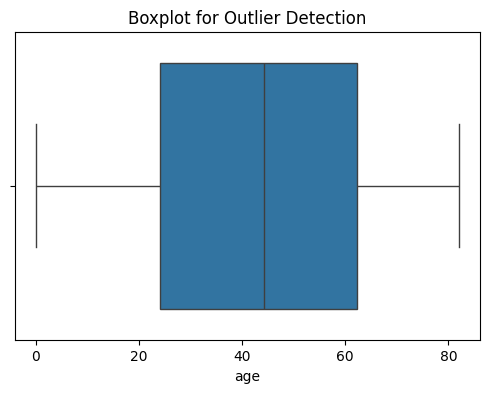

In [43]:
Q1 = total_data["age"].quantile(0.25)
Q3 = total_data["age"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = (total_data["age"] < lower_bound) | (total_data["age"] > upper_bound)

print("Outliers using IQR method:")
print(outliers.sum())

# Create a boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=total_data["age"])

plt.title("Boxplot for Outlier Detection")
plt.show()

Outliers using IQR method:
1001


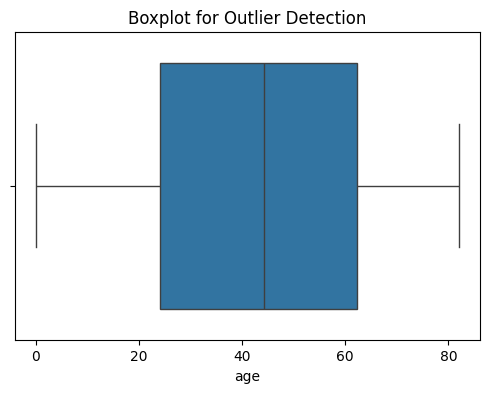

In [44]:
Q1 = total_data["hypertension"].quantile(0.25)
Q3 = total_data["hypertension"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = (total_data["hypertension"] < lower_bound) | (
    total_data["hypertension"] > upper_bound
)

print("Outliers using IQR method:")
print(outliers.sum())

# Create a boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=total_data["age"])

plt.title("Boxplot for Outlier Detection")
plt.show()

Outliers using IQR method:
555


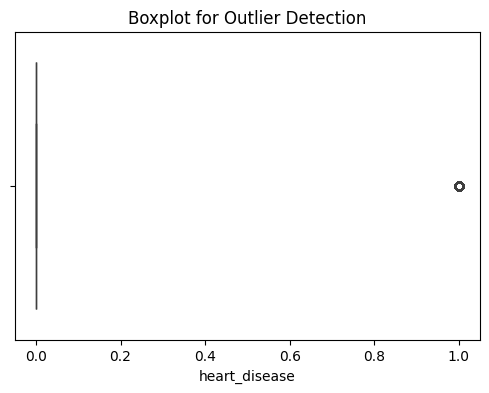

In [45]:
Q1 = total_data["heart_disease"].quantile(0.25)
Q3 = total_data["heart_disease"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = (total_data["heart_disease"] < lower_bound) | (
    total_data["heart_disease"] > upper_bound
)

print("Outliers using IQR method:")
print(outliers.sum())

# Create a boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=total_data["heart_disease"])

plt.title("Boxplot for Outlier Detection")
plt.show()

Outliers using IQR method:
302


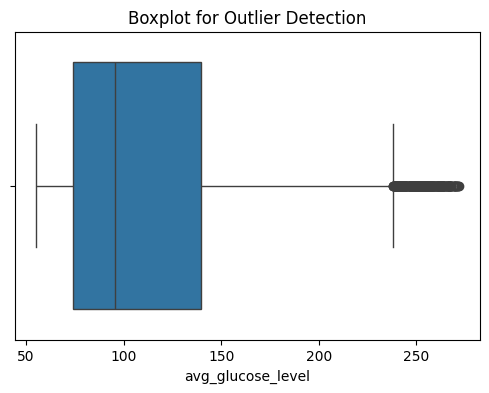

In [46]:
Q1 = total_data["avg_glucose_level"].quantile(0.25)
Q3 = total_data["avg_glucose_level"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = (total_data["avg_glucose_level"] < lower_bound) | (
    total_data["avg_glucose_level"] > upper_bound
)

print("Outliers using IQR method:")
print(outliers.sum())

# Create a boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=total_data["avg_glucose_level"])

plt.title("Boxplot for Outlier Detection")
plt.show()

Outliers using IQR method:
201


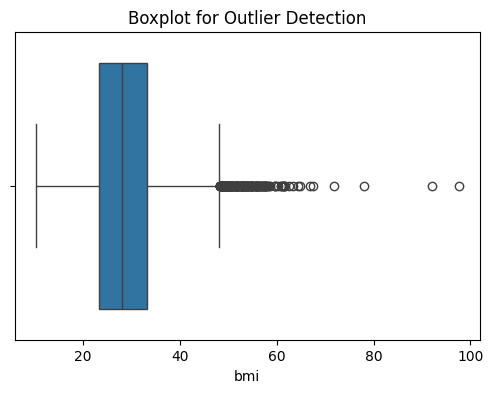

In [47]:
Q1 = total_data["bmi"].quantile(0.25)
Q3 = total_data["bmi"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = (total_data["bmi"] < lower_bound) | (total_data["bmi"] > upper_bound)

print("Outliers using IQR method:")
print(outliers.sum())

# Create a boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=total_data["bmi"])

plt.title("Boxplot for Outlier Detection")
plt.show()

Outliers using IQR method:
505


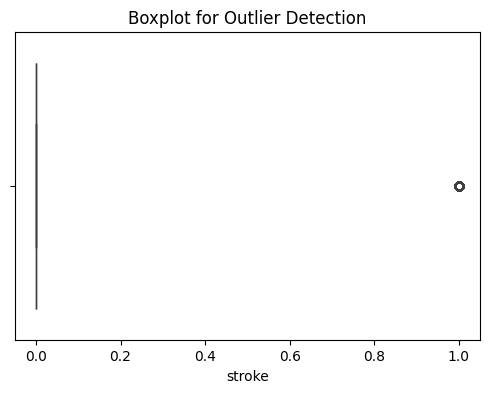

In [48]:
Q1 = total_data["stroke"].quantile(0.25)
Q3 = total_data["stroke"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = (total_data["stroke"] < lower_bound) | (total_data["stroke"] > upper_bound)

print("Outliers using IQR method:")
print(outliers.sum())

# Create a boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=total_data["stroke"])

plt.title("Boxplot for Outlier Detection")
plt.show()